# Ancestry-stratified analysis, genetic PCs, and caregiver-reported race/ethnicity

1. **Ancestry analysis:** refit the primary General Exposome-white matter model within the genetically defined European-ancestry subset from `Residual_ABCD_EUR_Mallard_Factor_1_PRS.csv`.
2. **Genetic population-structure sensitivity:** adjust the primary models for ABCD genetic PC1-PC10.
3. **Racial/ethnic social-context sensitivity:** separately adjust for ABCD baseline parent/caregiver-reported youth race/ethnicity (`ab_g_stc__cohort_ethnrace__leg`).

The ancestry-stratified models use the **same primary model specification** as the main analysis (`WM ~ General Exposome + age + sex + image quality`) and do **not** additionally adjust for race/ethnicity or genetic PCs. The PC- and race/ethnicity-adjusted models remain separate sensitivities because these constructs are not interchangeable.

In [1]:
from pathlib import Path
import re
import gc
import importlib
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, linregress
import statsmodels.api as sm
import matplotlib.pyplot as plt

import partial_r as pr
importlib.reload(pr)

<module 'partial_r' from '/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/code/partial_r.py'>

In [15]:
ROOT_DIR = Path('/mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome')
RESULTS_DIR = ROOT_DIR / 'output_data' / 'results'
OUTPUT_DIR = RESULTS_DIR / 'reviewer_revision' / 'reviewer2_ancestry_race'
FIG_DIR = ROOT_DIR / 'figures' / 'reviewer2_ancestry_race'
INPUT_DIR = ROOT_DIR.parent / 'input_data'
EUR_FILE = ROOT_DIR / "input_data" / "Residual_ABCD_EUR_Mallard_Factor_1_PRS.csv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILES = {'A_combined': RESULTS_DIR / 'dfA_macro_plus_NODDI_12_10.csv', 'B_combined': RESULTS_DIR / 'dfB_macro_plus_NODDI_12_10.csv'}
PHENO_DIR = Path('/mnt/isilon/bgdlab_hbcd/shared_data/ABCD/LASSO_tabular_tmp/abcd/rawdata/phenotype')
STATIC_FILE = PHENO_DIR / 'ab_g_stc.parquet'

N_PCS = 10
RACE_VAR_RAW = 'ab_g_stc__cohort_ethnrace__leg'
MASS_UNIVARIATE_QC = 't1post_dwi_contrast'
TARGET = 'General_SES'

print('OUTPUT_DIR:', OUTPUT_DIR)
print('STATIC_FILE:', STATIC_FILE, '| exists=', STATIC_FILE.exists())
print('EUR_FILE:', EUR_FILE, '| exists=', EUR_FILE.exists())
print('AFR_FILE:', AFR_FILE, '| exists=', AFR_FILE.exists())
for name, path in DATA_FILES.items():
    print(f'{name}: {path} | exists={path.exists()}')

OUTPUT_DIR: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/reviewer2_ancestry_race
STATIC_FILE: /mnt/isilon/bgdlab_hbcd/shared_data/ABCD/LASSO_tabular_tmp/abcd/rawdata/phenotype/ab_g_stc.parquet | exists= True
EUR_FILE: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/input_data/Residual_ABCD_EUR_Mallard_Factor_1_PRS.csv | exists= True
AFR_FILE: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/input_data/ext_scz_PGIs_resid_AFR.csv | exists= False
A_combined: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfA_macro_plus_NODDI_12_10.csv | exists=True
B_combined: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/dfB_macro_plus_NODDI_12_10.csv | exists=True


## 1. Load ABCD genetic PCs and caregiver-reported race/ethnicity

ABCD Release 6.0 documents `ab_g_stc__cohort_ethnrace__leg` as a five-level race/ethnicity variable constructed from parent/caregiver report of the youth at baseline. The categories prioritize Hispanic ethnicity and otherwise classify White, Black, Asian, or Other/multiracial responses.

We retain the raw race/ethnicity category for descriptives and create dummy variables for regression. The most frequent category in the static table is used as the reference level; the choice of reference level does **not** change the General Exposome coefficient when the full categorical block is included.


In [3]:
static = pd.read_parquet(STATIC_FILE)
print('Static table shape:', static.shape)

if 'participant_id' not in static.columns:
    raise ValueError('Expected participant_id in ab_g_stc.parquet')
if RACE_VAR_RAW not in static.columns:
    raise ValueError(f'Missing expected race/ethnicity variable: {RACE_VAR_RAW}')

pc_candidates = sorted([c for c in static.columns if c.startswith('ab_g_stc__gen_pc__')], 
                       key=lambda c: int(re.search(r'(\d+)$', c).group(1)))

if len(pc_candidates) < N_PCS:
    raise ValueError(f'Expected at least {N_PCS} genetic PCs; found {len(pc_candidates)}')

PC_COLS_RAW = pc_candidates[:N_PCS]
PC_COLS = [f'genPC{i}' for i in range(1, N_PCS + 1)]

print(f'Using PC1-PC{N_PCS}:')
print(PC_COLS_RAW)
print('\nRaw caregiver-reported race/ethnicity counts:')
display(static[RACE_VAR_RAW].value_counts(dropna=False).to_frame('n'))

Static table shape: (11860, 147)
Using PC1-PC10:
['ab_g_stc__gen_pc__01', 'ab_g_stc__gen_pc__02', 'ab_g_stc__gen_pc__03', 'ab_g_stc__gen_pc__04', 'ab_g_stc__gen_pc__05', 'ab_g_stc__gen_pc__06', 'ab_g_stc__gen_pc__07', 'ab_g_stc__gen_pc__08', 'ab_g_stc__gen_pc__09', 'ab_g_stc__gen_pc__10']

Raw caregiver-reported race/ethnicity counts:


,n
ab_g_stc__cohort_ethnrace__leg,
2,6185
1,2443
3,1815
13,1186
4,230
None,1


In [4]:
def clean_abcd_id(series):
    """Normalize common ABCD ID prefixes to match subject_id_clean."""
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r'^sub-', '', regex=True)
        .str.replace(r'^NDAR_', '', regex=True)
        .str.replace(r'^NDAR', '', regex=True)
        .str.replace(r'^INV', '', regex=True)
    )

# Participant-level covariate table only: ID + PCs + race/ethnicity.
person = static[['participant_id', RACE_VAR_RAW] + PC_COLS_RAW].copy()
person['subject_id_clean'] = clean_abcd_id(person['participant_id'])
person[PC_COLS_RAW] = person[PC_COLS_RAW].apply(pd.to_numeric, errors='coerce')
person = person.rename(columns=dict(zip(PC_COLS_RAW, PC_COLS)))

# Preserve missingness while normalizing display strings.
race = person[RACE_VAR_RAW].astype('string').str.strip()
race = race.mask(race.isin(['', 'nan', 'NaN', 'None', '<NA>']))
person['race_ethnicity'] = race

# Use the most common category as the reference level (typically White in ABCD).
race_levels = person['race_ethnicity'].dropna().value_counts().index.tolist()
if len(race_levels) < 2:
    raise ValueError(f'Expected multiple race/ethnicity categories; found: {race_levels}')

race_cat = pd.Series(pd.Categorical(person['race_ethnicity'], categories=race_levels), index=person.index, name='race_ethnicity')
race_dummies = pd.get_dummies(race_cat, prefix='raceeth', drop_first=True, dtype=float)

RACE_REFERENCE = str(race_levels[0])
RACE_DUMMY_COLS = race_dummies.columns.tolist()
person = pd.concat([person, race_dummies], axis=1)

# One row per participant is required for a clean many-to-one merge.
dup_n = int(person['subject_id_clean'].duplicated().sum())
print('Duplicated cleaned participant IDs:', dup_n)
if dup_n:
    display(person.loc[person['subject_id_clean'].duplicated(keep=False), ['participant_id', 'subject_id_clean']].head(10))
    raise ValueError('Duplicate cleaned participant IDs found in ab_g_stc; inspect before merging.')

print('\nRace/ethnicity levels, most frequent first:')
print(race_levels)
print('Regression reference level:', RACE_REFERENCE)
print('Race/ethnicity dummy columns:')
print(RACE_DUMMY_COLS)
print('\nPC missingness:')
display(person[PC_COLS].isna().sum().rename('n_missing').to_frame())

Duplicated cleaned participant IDs: 0

Race/ethnicity levels, most frequent first:
['2', '1', '3', '13', '4']
Regression reference level: 2
Race/ethnicity dummy columns:
['raceeth_1', 'raceeth_3', 'raceeth_13', 'raceeth_4']

PC missingness:


,n_missing
genPC1,190
genPC2,190
genPC3,190
genPC4,190
genPC5,190
genPC6,190
genPC7,190
genPC8,190
genPC9,190
genPC10,190


## 2. Load the Figure-2 combined white-matter tables and create one common analysis sample

To keep memory use low, this version loads only the two combined NODDI + macrostructure tables needed for the Figure 2 mass-univariate analysis. It applies the same split-half filtering and bundle-column cleanup as the current Figure 2 workflow.

For a clean three-way comparison, each split is then restricted to participants with **both** complete PC1–PC10 and nonmissing caregiver-reported race/ethnicity. Thus the reference, PC-adjusted, and race/ethnicity-adjusted models use exactly the same participants within each split.


In [5]:
def clean_bundle_columns_inplace(df):
    """Match Figure 2: drop *_mean bundle summaries and use median summaries."""
    mean_cols = [c for c in df.columns if c.startswith('bundle_') and c.endswith('_mean')]
    if mean_cols: df.drop(columns=mean_cols, inplace=True)

    rename_map = {c: c[:-len('_median')] for c in df.columns if c.startswith('bundle_') and c.endswith('_median')}
    if rename_map: df.rename(columns=rename_map, inplace=True)

analysis_dfs = {}
sample_rows = []

merge_cols = ['subject_id_clean', 'race_ethnicity'] + PC_COLS + RACE_DUMMY_COLS

for name, path in DATA_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing Figure 2 input: {path}')

    print(f'\nLoading {name}...')
    df = pd.read_csv(path)

    split = name[0]
    expected_group = 1 if split == 'A' else 2
    if 'matched_group' not in df.columns:
        raise ValueError(f'{name} is missing matched_group')

    # Filter immediately to avoid retaining unnecessary participants.
    df = df.loc[df['matched_group'] == expected_group].copy()
    n_split = len(df)

    clean_bundle_columns_inplace(df)
    df['subject_id_clean'] = clean_abcd_id(df['subject_id_clean'])

    df = df.merge(
        person[merge_cols],
        on='subject_id_clean',
        how='left',
        validate='many_to_one',
        indicator='_static_merge',
    )

    n_static_match = int((df['_static_merge'] == 'both').sum())
    df.drop(columns='_static_merge', inplace=True)

    complete_pc = df[PC_COLS].notna().all(axis=1)
    complete_race = df['race_ethnicity'].notna()
    common_complete = complete_pc & complete_race

    n_pc = int(complete_pc.sum())
    n_race = int(complete_race.sum())
    n_common = int(common_complete.sum())

    # Restrict in place to the intersection sample used for ALL three models.
    df = df.loc[common_complete].reset_index(drop=True)
    analysis_dfs[split] = df

    sample_rows.append({
        'split': split,
        'n_after_matched_group': n_split,
        'n_static_match': n_static_match,
        'n_complete_PC1_PC10': n_pc,
        'n_complete_race_ethnicity': n_race,
        'n_common_complete': n_common,
    })

    print(
        f'{split}: {n_split} split participants -> {n_static_match} static-table match -> '
        f'{n_common} complete PCs + race/ethnicity'
    )

sample_sizes = pd.DataFrame(sample_rows).sort_values('split')
display(sample_sizes)
sample_sizes.to_csv(OUTPUT_DIR / 'common_sample_sizes_PC_and_race.csv', index=False)

# Feature sanity check.
features_A = [c for c in analysis_dfs['A'].columns if c.startswith('bundle_')]
features_B = [c for c in analysis_dfs['B'].columns if c.startswith('bundle_')]
if features_A != features_B:
    raise ValueError('A/B tables do not contain identical ordered bundle_ feature columns')
features = features_A
print('\nNumber of Figure-2-style WM features:', len(features))
if len(features) != 1302:
    print('WARNING: expected 1,302 WM features. Inspect before interpreting results.')

# Ensure each race dummy varies in both splits; constant columns can be dropped safely.
RACE_DUMMY_COLS_ANALYSIS = [
    c for c in RACE_DUMMY_COLS
    if analysis_dfs['A'][c].nunique(dropna=True) > 1
    and analysis_dfs['B'][c].nunique(dropna=True) > 1
]
omitted_race_dummies = [c for c in RACE_DUMMY_COLS if c not in RACE_DUMMY_COLS_ANALYSIS]
print('Race/ethnicity dummy columns used:', RACE_DUMMY_COLS_ANALYSIS)
if omitted_race_dummies:
    print('Dropped constant race/ethnicity dummy columns:', omitted_race_dummies)

# Descriptive race/ethnicity composition in the exact analysis sample.
race_counts = pd.concat(
    [
        analysis_dfs[split]['race_ethnicity']
        .value_counts(dropna=False)
        .rename_axis('race_ethnicity')
        .reset_index(name='n')
        .assign(split=split)
        for split in ['A', 'B']
    ],
    ignore_index=True,
)
race_counts['percent'] = race_counts.groupby('split')['n'].transform(lambda x: 100 * x / x.sum())
display(race_counts[['split', 'race_ethnicity', 'n', 'percent']].round({'percent': 1}))
race_counts.to_csv(OUTPUT_DIR / 'race_ethnicity_counts_common_sample.csv', index=False)

# Static table no longer needed; release it before running 1,302 regressions x 6 models.
del static, person, race_dummies, race_cat
gc.collect()


Loading A_combined...
A: 4078 split participants -> 4076 static-table match -> 4026 complete PCs + race/ethnicity

Loading B_combined...
B: 4096 split participants -> 4094 static-table match -> 4053 complete PCs + race/ethnicity


,split,n_after_matched_group,n_static_match,n_complete_PC1_PC10,n_complete_race_ethnicity,n_common_complete
0,A,4078,4076,4026,4076,4026
1,B,4096,4094,4054,4093,4053



Number of Figure-2-style WM features: 1302
Race/ethnicity dummy columns used: ['raceeth_1', 'raceeth_3', 'raceeth_13', 'raceeth_4']


,split,race_ethnicity,n,percent
0,A,2,2195,54.5
1,A,1,860,21.4
2,A,3,505,12.5
3,A,13,381,9.5
4,A,4,85,2.1
5,B,2,2211,54.6
6,B,1,803,19.8
7,B,3,542,13.4
8,B,13,419,10.3
9,B,4,78,1.9


36

## 3. Primary mass-univariate sensitivity analyses

All models below use the same common-complete participants within each split.

- **Reference:** `WM ~ General Exposome + age + sex + image quality`
- **Genetic-PC adjusted:** reference + `PC1 ... PC10`
- **Race/ethnicity adjusted:** reference + dummy-coded caregiver-reported race/ethnicity

The General Exposome remains the target predictor in every model.


In [6]:
base_covars = ['age', 'sex', MASS_UNIVARIATE_QC, TARGET]
pc_covars = base_covars + PC_COLS
race_covars = base_covars + RACE_DUMMY_COLS_ANALYSIS

mu = {}

for split in ['A', 'B']:
    df = analysis_dfs[split]
    print(f'\n========== SPLIT {split} | N={len(df)} ==========')

    print('Running reference model...')
    mu[(split, 'base')] = pr.run_partial_r(df=df, msmt_cols=features, covariates=base_covars, target_cov=TARGET)

    print('Running PC1-PC10-adjusted model...')
    mu[(split, 'pc')] = pr.run_partial_r(df=df, msmt_cols=features, covariates=pc_covars, target_cov=TARGET)

    print('Running caregiver-reported race/ethnicity-adjusted model...')
    mu[(split, 'race')] = pr.run_partial_r(df=df, msmt_cols=features, covariates=race_covars, target_cov=TARGET)

    for label in ['base', 'pc', 'race']:
        mu[(split, label)].to_csv(OUTPUT_DIR / f'mass_univariate_{split}_{label}_common_sample.csv', index=False)


========== SPLIT A | N=4026 ==========
Running reference model...
Running PC1-PC10-adjusted model...
Running caregiver-reported race/ethnicity-adjusted model...

========== SPLIT B | N=4053 ==========
Running reference model...
Running PC1-PC10-adjusted model...
Running caregiver-reported race/ethnicity-adjusted model...


## 4. Compare how PC adjustment and race/ethnicity adjustment change the General Exposome effects

The main comparison quantities are effect-map concordance with the reference model, regression slope versus the reference effects, mean absolute effect magnitude, relative attenuation, sign agreement, and the number of FDR-significant white-matter features.


In [7]:
def pearson_r(x, y):
    res = pearsonr(x, y)
    return float(res.statistic if hasattr(res, 'statistic') else res[0])

comparison_rows = []
direct_rows = []

for split in ['A', 'B']:
    n = len(analysis_dfs[split])

    base = mu[(split, 'base')][['feature', 'partial_r', 'p_fdr']].rename(
        columns={'partial_r': 'r_base', 'p_fdr': 'q_base'})

    model_tables = {}
    for label in ['pc', 'race']:
        short = 'pc' if label == 'pc' else 'race'
        adj = mu[(split, label)][['feature', 'partial_r', 'p_fdr']].rename(
            columns={'partial_r': f'r_{short}', 'p_fdr': f'q_{short}'})
        m = base.merge(adj, on='feature', validate='one_to_one')
        model_tables[label] = m

        x = m['r_base'].to_numpy(float)
        y = m[f'r_{short}'].to_numpy(float)
        delta = y - x
        slope = linregress(x, y).slope
        mean_abs_base = float(np.mean(np.abs(x)))
        mean_abs_adj = float(np.mean(np.abs(y)))
        attenuation = 1 - (mean_abs_adj / mean_abs_base) if mean_abs_base > 0 else np.nan

        comparison_rows.append({
            'split': split,
            'n': n,
            'adjustment': 'PC1-PC10' if label == 'pc' else 'caregiver race/ethnicity',
            'effect_concordance_vs_reference': pearson_r(x, y),
            'slope_vs_reference': float(slope),
            'mean_abs_r_reference': mean_abs_base,
            'mean_abs_r_adjusted': mean_abs_adj,
            'relative_reduction_mean_abs_r': float(attenuation),
            'mean_abs_delta_r': float(np.mean(np.abs(delta))),
            'max_abs_delta_r': float(np.max(np.abs(delta))),
            'sign_agreement': float(np.mean(np.sign(x) == np.sign(y))),
            'n_FDR_reference': int((m['q_base'] < .05).sum()),
            'n_FDR_adjusted': int((m[f'q_{short}'] < .05).sum()),
        })

        m.to_csv(
            OUTPUT_DIR / f'mass_univariate_{split}_reference_vs_{short}.csv',
            index=False,
        )

    # Directly compare the two adjusted maps on the exact same features/participants.
    pc_race = (
        mu[(split, 'pc')][['feature', 'partial_r']]
        .rename(columns={'partial_r': 'r_pc'})
        .merge(
            mu[(split, 'race')][['feature', 'partial_r']]
            .rename(columns={'partial_r': 'r_race'}),
            on='feature',
            validate='one_to_one',
        )
    )
    direct_rows.append({
        'split': split,
        'n': n,
        'PC_vs_race_effect_concordance': pearson_r(pc_race['r_pc'], pc_race['r_race']),
        'mean_abs_PC_minus_race_r': float((pc_race['r_pc'] - pc_race['r_race']).abs().mean()),
    })

comparison_summary = pd.DataFrame(comparison_rows)
direct_summary = pd.DataFrame(direct_rows)

print('\nAdjustment vs reference:')
display(comparison_summary.round(4))
print('\nPC-adjusted vs race/ethnicity-adjusted maps:')
display(direct_summary.round(4))

comparison_summary.to_csv(OUTPUT_DIR / 'PC_and_race_adjustment_summary.csv', index=False)
direct_summary.to_csv(OUTPUT_DIR / 'PC_vs_race_direct_comparison.csv', index=False)

# Split-half reproducibility for each model.
def split_half_r(model_label):
    A = mu[('A', model_label)][['feature', 'partial_r']].rename(columns={'partial_r': 'r_A'})
    B = mu[('B', model_label)][['feature', 'partial_r']].rename(columns={'partial_r': 'r_B'})
    ab = A.merge(B, on='feature', validate='one_to_one')
    return pearson_r(ab['r_A'], ab['r_B'])

split_summary = pd.DataFrame([
    {'model': 'reference', 'split_half_effect_concordance': split_half_r('base')},
    {'model': 'PC1-PC10 adjusted', 'split_half_effect_concordance': split_half_r('pc')},
    {'model': 'caregiver race/ethnicity adjusted', 'split_half_effect_concordance': split_half_r('race')},
])
print('\nSplit-half effect-map concordance:')
display(split_summary.round(4))
split_summary.to_csv(OUTPUT_DIR / 'split_half_concordance_three_models.csv', index=False)


Adjustment vs reference:


,split,n,adjustment,effect_concordance_vs_reference,slope_vs_reference,mean_abs_r_reference,mean_abs_r_adjusted,relative_reduction_mean_abs_r,mean_abs_delta_r,max_abs_delta_r,sign_agreement,n_FDR_reference,n_FDR_adjusted
0,A,4026,PC1-PC10,0.8865,0.4723,0.0937,0.0483,0.4845,0.0508,0.1601,0.8786,1111,774
1,A,4026,caregiver race/ethnicity,0.9434,0.5751,0.0937,0.0553,0.4096,0.0416,0.1398,0.9293,1111,857
2,B,4053,PC1-PC10,0.8505,0.4547,0.0844,0.0410,0.5144,0.0527,0.1769,0.8018,1009,661
3,B,4053,caregiver race/ethnicity,0.8926,0.5350,0.0844,0.0445,0.4729,0.0481,0.1537,0.8295,1009,686



PC-adjusted vs race/ethnicity-adjusted maps:


,split,n,PC_vs_race_effect_concordance,mean_abs_PC_minus_race_r
0,A,4026,0.9812,0.0103
1,B,4053,0.9852,0.0077



Split-half effect-map concordance:


,model,split_half_effect_concordance
0,reference,0.9433
1,PC1-PC10 adjusted,0.8201
2,caregiver race/ethnicity adjusted,0.8252


## 5. How much of the General Exposome is associated with each covariate block?

This is a descriptive sensitivity analysis of the **exposure itself**. For the same participants, we compare the additional variance in General Exposome scores associated with:

- PC1–PC10, beyond age, sex, and image quality;
- caregiver-reported race/ethnicity, beyond age, sex, and image quality.

These quantities should not be interpreted as genetic ancestry or race *causing* the General Exposome. They quantify statistical alignment between each covariate block and the environmental composite.


In [8]:
def block_exposure_r2(df, split_label, block_label, block_cols):
    base_covs = ['age', 'sex', MASS_UNIVARIATE_QC]
    cols = [TARGET] + base_covs + list(block_cols)
    dat = df[cols].dropna().copy()

    y = dat[TARGET].astype(float)
    X_base = sm.add_constant(dat[base_covs].astype(float), has_constant='add')
    X_block = sm.add_constant(dat[base_covs + list(block_cols)].astype(float), has_constant='add')

    model_base = sm.OLS(y, X_base).fit()
    model_block = sm.OLS(y, X_block).fit()

    delta_r2 = model_block.rsquared - model_base.rsquared
    partial_r2 = delta_r2 / (1 - model_base.rsquared)

    return {
        'split': split_label,
        'block': block_label,
        'n': len(dat),
        'R2_age_sex_QC': model_base.rsquared,
        'R2_age_sex_QC_plus_block': model_block.rsquared,
        'delta_R2_block': delta_r2,
        'partial_R2_block': partial_r2,
    }

block_rows = []
for split in ['A', 'B']:
    df = analysis_dfs[split]
    block_rows.append(block_exposure_r2(df, split, 'PC1-PC10', PC_COLS))
    block_rows.append(block_exposure_r2(df, split, 'caregiver race/ethnicity', RACE_DUMMY_COLS_ANALYSIS))

exposure_block_summary = pd.DataFrame(block_rows)
print('Additional General Exposome variance associated with each block:')
display(exposure_block_summary.round(4))
exposure_block_summary.to_csv(OUTPUT_DIR / 'GeneralExposome_variance_by_PC_and_race_blocks.csv', index=False)

# Descriptive General Exposome means by caregiver-reported race/ethnicity.
race_exposome_rows = []
for split in ['A', 'B']:
    tmp = (
        analysis_dfs[split]
        .groupby('race_ethnicity', observed=True)[TARGET]
        .agg(['count', 'mean', 'std'])
        .reset_index()
    )
    tmp.insert(0, 'split', split)
    race_exposome_rows.append(tmp)

race_exposome = pd.concat(race_exposome_rows, ignore_index=True)
print('\nGeneral Exposome descriptives by caregiver-reported race/ethnicity:')
display(race_exposome.round(3))
race_exposome.to_csv(OUTPUT_DIR / 'GeneralExposome_by_race_ethnicity.csv', index=False)


Additional General Exposome variance associated with each block:


,split,block,n,R2_age_sex_QC,R2_age_sex_QC_plus_block,delta_R2_block,partial_R2_block
0,A,PC1-PC10,4026,0.0146,0.4012,0.3865,0.3923
1,A,caregiver race/ethnicity,4026,0.0146,0.3126,0.2980,0.3024
2,B,PC1-PC10,4053,0.0080,0.4087,0.4007,0.4040
3,B,caregiver race/ethnicity,4053,0.0080,0.3299,0.3219,0.3245



General Exposome descriptives by caregiver-reported race/ethnicity:


,split,race_ethnicity,count,mean,std
0,A,1,860,-0.447,0.920
1,A,13,381,0.008,0.977
2,A,2,2195,0.411,0.757
3,A,3,505,-1.135,0.880
4,A,4,85,0.739,0.675
5,B,1,803,-0.512,0.930
6,B,13,419,-0.050,1.045
7,B,2,2211,0.429,0.748
8,B,3,542,-1.189,0.889
9,B,4,78,0.519,0.843


## 6. Compact comparison figure

Each panel compares the 1,302 General Exposome partial-*r* estimates from the reference model with either the PC-adjusted or race/ethnicity-adjusted model. The identity line shows where effects would fall if adjustment made no difference. The fitted slope and correlation summarize attenuation and preservation of the overall effect pattern.

This figure is intentionally small and saved at 250 dpi to avoid the memory spike caused by very large high-DPI heatmaps.


Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/figures/reviewer2_ancestry_race/GeneralExposome_reference_vs_PC_and_race_adjustment.png


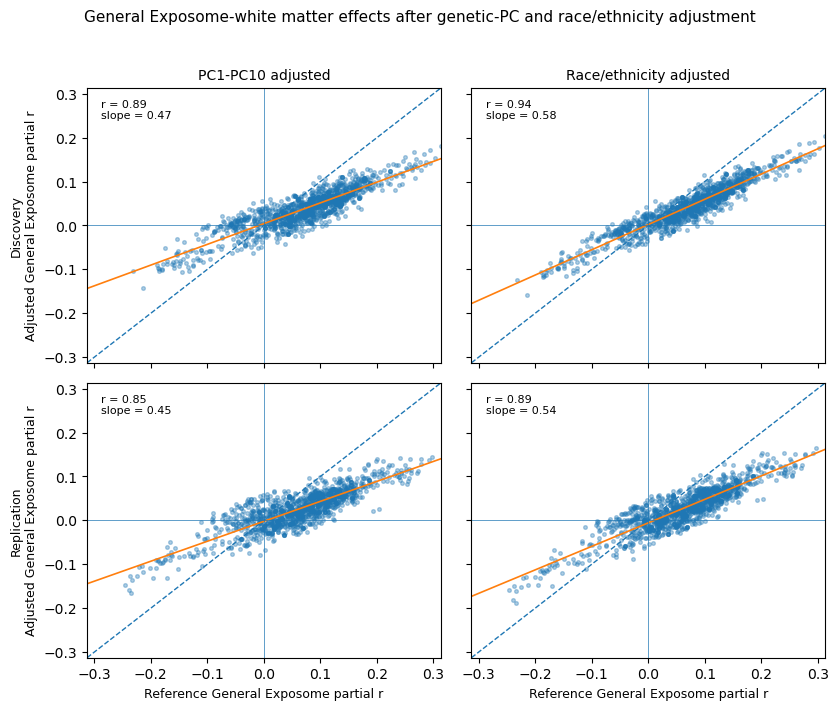

21

In [9]:
plt.close('all')
gc.collect()

# Use one global axis limit across all four panels so the shared axes are
# directly comparable and no panel is clipped by a later limit update.
all_plot_vals = []
for split in ['A', 'B']:
    for label in ['base', 'pc', 'race']:
        all_plot_vals.append(mu[(split, label)]['partial_r'].to_numpy(float))
global_lim = max(np.max(np.abs(v)) for v in all_plot_vals)

fig, axes = plt.subplots(2, 2, figsize=(8.5, 7.2), sharex=True, sharey=True)

for row, split in enumerate(['A', 'B']):
    base = mu[(split, 'base')][['feature', 'partial_r']].rename(columns={'partial_r': 'r_base'})

    for col, (label, pretty) in enumerate([
        ('pc', 'PC1-PC10 adjusted'),
        ('race', 'Race/ethnicity adjusted'),
    ]):
        adj = mu[(split, label)][['feature', 'partial_r']].rename(columns={'partial_r': 'r_adj'})
        m = base.merge(adj, on='feature', validate='one_to_one')

        x = m['r_base'].to_numpy(float)
        y = m['r_adj'].to_numpy(float)
        r = pearson_r(x, y)
        fit = linregress(x, y)

        ax = axes[row, col]
        ax.scatter(x, y, s=7, alpha=.35, rasterized=True)

        ax.plot([-global_lim, global_lim], [-global_lim, global_lim], '--', linewidth=1, label='identity')
        xx = np.linspace(-global_lim, global_lim, 100)
        ax.plot(xx, fit.intercept + fit.slope * xx, linewidth=1.2, label='fit')
        ax.axhline(0, linewidth=.5)
        ax.axvline(0, linewidth=.5)
        ax.set_xlim(-global_lim, global_lim)
        ax.set_ylim(-global_lim, global_lim)

        if row == 0:
            ax.set_title(pretty, fontsize=10)
        if col == 0:
            ax.set_ylabel(
                ('Discovery' if split == 'A' else 'Replication') +
                '\nAdjusted General Exposome partial r',
                fontsize=9,
            )
        if row == 1:
            ax.set_xlabel('Reference General Exposome partial r', fontsize=9)

        ax.text(
            .04, .96,
            f'r = {r:.2f}\nslope = {fit.slope:.2f}',
            transform=ax.transAxes,
            ha='left', va='top', fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=.8),
        )

fig.suptitle(
    'General Exposome-white matter effects after genetic-PC and race/ethnicity adjustment',
    fontsize=11,
)
fig.tight_layout(rect=[0, 0, 1, .96])

plot_path = FIG_DIR / 'GeneralExposome_reference_vs_PC_and_race_adjustment.png'
fig.savefig(plot_path, dpi=250)
print('Saved:', plot_path)
plt.show()
plt.close(fig)
gc.collect()


## 7. Race/ethnicity descriptives and PC/race sensitivity heatmap

The Table 1 descriptives use the full primary ABCD split-half sample. The heatmap below summarizes the common-sample reference, race/ethnicity-adjusted, and PC-adjusted sensitivity models and now reports N, mean absolute partial *r*, and the number of FDR-significant WM features in every panel.


In [10]:
# ============================================================
# Race/ethnicity descriptives for manuscript Table 1
# FULL primary ABCD analysis sample (not PC-complete subset)
# ============================================================

import pandas as pd
import numpy as np

RACE_VAR_RAW = "ab_g_stc__cohort_ethnrace__leg"

# Load ID + race/ethnicity from ABCD static table
race_static = pd.read_parquet(
    STATIC_FILE,
    columns=["participant_id", RACE_VAR_RAW]
)

race_static["subject_id_clean"] = clean_abcd_id(race_static["participant_id"])
race_static["race_ethnicity"] = race_static[RACE_VAR_RAW].astype("string").str.strip()
race_static["race_ethnicity"] = race_static["race_ethnicity"].mask(
    race_static["race_ethnicity"].isin(["", "nan", "NaN", "None", "<NA>"])
)

race_static = race_static[
    ["subject_id_clean", "race_ethnicity"]
].drop_duplicates("subject_id_clean")

# Get participants from primary split-half sample
table1_rows = []

for split, path, expected_group in [
    ("Discovery", DATA_FILES["A_combined"], 1),
    ("Replication", DATA_FILES["B_combined"], 2),
]:
    ids = pd.read_csv(path, usecols=["subject_id_clean", "matched_group"])
    ids = ids.loc[ids["matched_group"] == expected_group].copy()
    ids["subject_id_clean"] = clean_abcd_id(ids["subject_id_clean"])

    ids = ids.merge(
        race_static,
        on="subject_id_clean",
        how="left",
        validate="many_to_one"
    )

    total_n = len(ids)

    counts = (
        ids["race_ethnicity"]
        .value_counts(dropna=False)
        .rename_axis("Race/ethnicity")
        .reset_index(name="n")
    )

    counts["Sample"] = split
    counts["Total N"] = total_n
    counts["Percent"] = 100 * counts["n"] / total_n
    table1_rows.append(counts)

race_table_long = pd.concat(table1_rows, ignore_index=True)

# Clean missing label
race_table_long["Race/ethnicity"] = (
    race_table_long["Race/ethnicity"]
    .astype("string")
    .fillna("Missing")
)

# Add combined sample
combined_counts = (
    race_table_long
    .groupby("Race/ethnicity", as_index=False)["n"]
    .sum()
)

combined_total = combined_counts["n"].sum()
combined_counts["Sample"] = "Combined"
combined_counts["Total N"] = combined_total
combined_counts["Percent"] = 100 * combined_counts["n"] / combined_total

race_table_long = pd.concat(
    [race_table_long, combined_counts],
    ignore_index=True
)

# Manuscript-style n (%)
race_table_long["n (%)"] = race_table_long.apply(
    lambda x: f"{int(x['n'])} ({x['Percent']:.1f}%)",
    axis=1
)

race_table_paper = (
    race_table_long
    .pivot(index="Race/ethnicity", columns="Sample", values="n (%)")
    .reindex(columns=["Discovery", "Replication", "Combined"])
)

print("\n==============================================")
print("Race/ethnicity — manuscript Table 1")
print("Caregiver-reported youth race/ethnicity")
print("==============================================\n")

display(race_table_paper)

# Sample sizes
sample_N = (
    race_table_long[["Sample", "Total N"]]
    .drop_duplicates()
    .set_index("Sample")
    .reindex(["Discovery", "Replication", "Combined"])
)

print("\nSample sizes:")
display(sample_N)

# Save outputs
race_table_long.to_csv(
    OUTPUT_DIR / "Table1_race_ethnicity_long.csv",
    index=False
)

race_table_paper.to_csv(
    OUTPUT_DIR / "Table1_race_ethnicity_paper_format.csv"
)

print("\nSaved:", OUTPUT_DIR / "Table1_race_ethnicity_paper_format.csv")



Race/ethnicity — manuscript Table 1
Caregiver-reported youth race/ethnicity



Sample,Discovery,Replication,Combined
Race/ethnicity,,,
1,873 (21.4%),813 (19.8%),1686 (20.6%)
13,384 (9.4%),426 (10.4%),810 (9.9%)
2,2225 (54.6%),2232 (54.5%),4457 (54.5%)
3,509 (12.5%),544 (13.3%),1053 (12.9%)
4,85 (2.1%),78 (1.9%),163 (2.0%)
Missing,2 (0.0%),3 (0.1%),5 (0.1%)



Sample sizes:


,Total N
Sample,
Discovery,4078
Replication,4096
Combined,8174



Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/reviewer2_ancestry_race/Table1_race_ethnicity_paper_format.csv


Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/figures/reviewer2_ancestry_race/SUPP_Race_PC_mass_univariate_heatmaps_with_stats.png


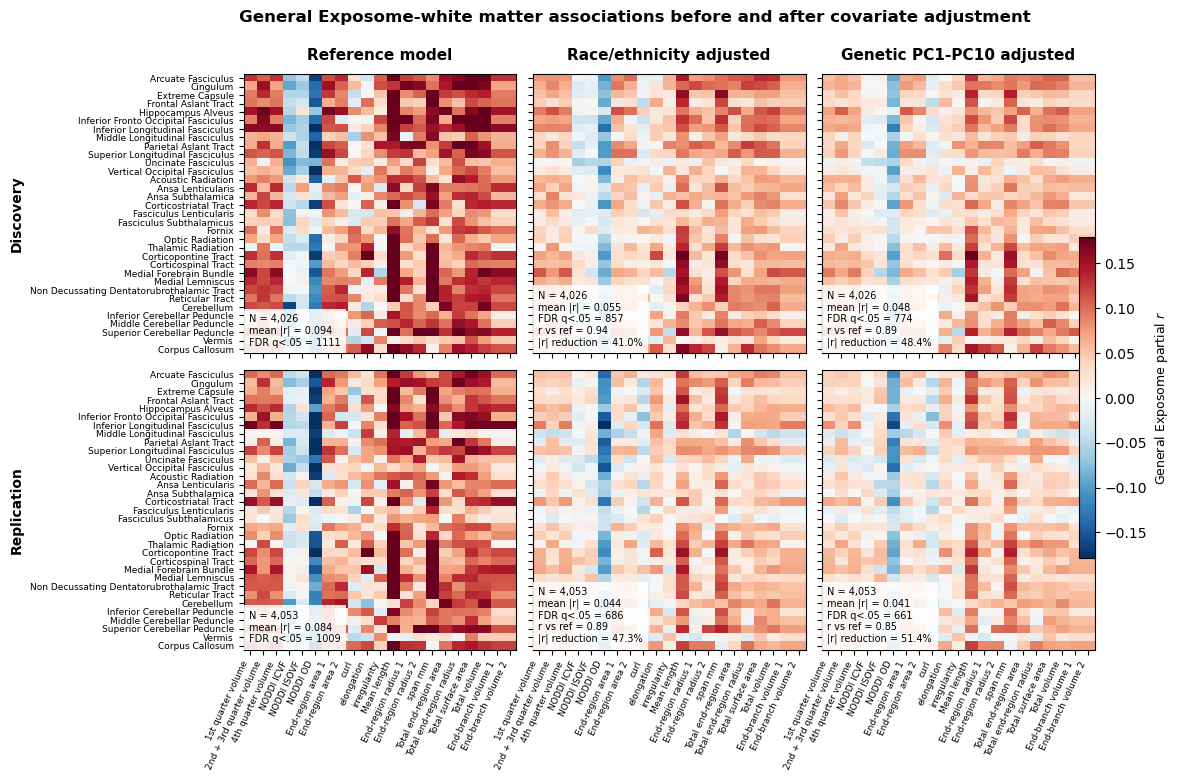

14280

In [11]:
# ============================================================
# PC/race sensitivity heatmaps with requested panel statistics
# Columns: Reference | Race/ethnicity adjusted | PC1-PC10 adjusted
# Rows: Discovery | Replication
# Each panel reports N, mean |r|, and number of FDR-significant features.
# ============================================================

import re, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import pearsonr

plt.close("all")
gc.collect()

METRIC_ORDER = [
    "1st_quarter_volume_mm3","2nd_and_3rd_quarter_volume_mm3","4th_quarter_volume_mm3",
    "NODDI_icvf","NODDI_isovf","NODDI_od","area_of_end_region_1_mm2",
    "area_of_end_region_2_mm2","curl","elongation","irregularity","mean_length_mm",
    "radius_of_end_region_1_mm","radius_of_end_region_2_mm","span_mm",
    "total_area_of_end_regions_mm2","total_radius_of_end_regions_mm",
    "total_surface_area_mm2","total_volume_mm3","volume_of_end_branches_1",
    "volume_of_end_branches_2"
]
FAMILY_ORDER = {"Association":0,"ProjectionBasalGanglia":1,"ProjectionBrainstem":2,"Cerebellum":3,"Commissure":4}

def pretty_metric(x):
    labels = {
        "NODDI_icvf":"NODDI ICVF","NODDI_isovf":"NODDI ISOVF","NODDI_od":"NODDI OD",
        "1st_quarter_volume_mm3":"1st quarter volume","2nd_and_3rd_quarter_volume_mm3":"2nd + 3rd quarter volume",
        "4th_quarter_volume_mm3":"4th quarter volume","area_of_end_region_1_mm2":"End-region area 1",
        "area_of_end_region_2_mm2":"End-region area 2","radius_of_end_region_1_mm":"End-region radius 1",
        "radius_of_end_region_2_mm":"End-region radius 2","total_area_of_end_regions_mm2":"Total end-region area",
        "total_radius_of_end_regions_mm":"Total end-region radius","total_surface_area_mm2":"Total surface area",
        "total_volume_mm3":"Total volume","mean_length_mm":"Mean length",
        "volume_of_end_branches_1":"End-branch volume 1","volume_of_end_branches_2":"End-branch volume 2",
    }
    return labels.get(x, x.replace("_"," "))

def camel_spaces(x):
    return re.sub(r"(?<!^)(?=[A-Z])", " ", str(x)).strip()

def parse_results(df):
    rows = []
    for feature, r in zip(df["feature"].values, df["partial_r"].values):
        feature = str(feature)
        if feature.endswith("_median"):
            feature = feature[:-len("_median")]
        if not feature.startswith("bundle_"):
            continue
        parts = feature[len("bundle_"):].split("_")
        if len(parts) < 3:
            continue
        family, tract_hemi = parts[0], parts[1]
        metric = "_".join(parts[2:])
        if metric not in METRIC_ORDER:
            continue
        tract = re.sub(r"(L|R)$", "", tract_hemi)
        rows.append((family, f"{family}::{tract}", camel_spaces(tract), metric, float(r)))
    out = pd.DataFrame(rows, columns=["family","tract_key","tract_label","metric","partial_r"])
    return out.groupby(["family","tract_key","tract_label","metric"], as_index=False)["partial_r"].mean()

parsed = {(split,model):parse_results(mu[(split,model)]) for split in ["A","B"] for model in ["base","race","pc"]}
tract_info = pd.concat([
    parsed[("A","base")][["family","tract_key","tract_label"]],
    parsed[("B","base")][["family","tract_key","tract_label"]]
], ignore_index=True).drop_duplicates()
tract_info["family_order"] = tract_info["family"].map(FAMILY_ORDER).fillna(99)
tract_info = tract_info.sort_values(["family_order","tract_label"]).reset_index(drop=True)
TRACT_ORDER = tract_info["tract_key"].tolist()
TRACT_LABELS = tract_info["tract_label"].tolist()

def make_matrix(df):
    return df.pivot(index="tract_key", columns="metric", values="partial_r").reindex(index=TRACT_ORDER, columns=METRIC_ORDER)

mats = {(split,model):make_matrix(parsed[(split,model)]) for split in ["A","B"] for model in ["base","race","pc"]}
vals = np.concatenate([m.to_numpy().ravel() for m in mats.values()])
vals = vals[np.isfinite(vals)]
vmax = np.nanpercentile(np.abs(vals), 98)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

panel_stats = {}
for split in ["A","B"]:
    base_r = mu[(split,"base")][["feature","partial_r"]].rename(columns={"partial_r":"r_base"})
    for model in ["base","race","pc"]:
        res = mu[(split,model)]
        s = {
            "n": len(analysis_dfs[split]),
            "mean_abs_r": float(np.mean(np.abs(res["partial_r"]))),
            "n_fdr": int((res["p_fdr"] < .05).sum()),
        }
        if model != "base":
            adj = res[["feature","partial_r"]].rename(columns={"partial_r":"r_adj"})
            comp = base_r.merge(adj, on="feature", validate="one_to_one")
            s["map_r"] = pearsonr(comp["r_base"], comp["r_adj"])[0]
            s["attenuation"] = 100 * (1 - np.mean(np.abs(comp["r_adj"])) / np.mean(np.abs(comp["r_base"])))
        panel_stats[(split,model)] = s

fig, axes = plt.subplots(2, 3, figsize=(11.5,8), sharex=True, sharey=True)
for col, title in enumerate(["Reference model","Race/ethnicity adjusted","Genetic PC1-PC10 adjusted"]):
    axes[0,col].set_title(title, fontsize=11, fontweight="bold", pad=10)

for row, split in enumerate(["A","B"]):
    for col, model in enumerate(["base","race","pc"]):
        ax = axes[row,col]
        im = ax.imshow(mats[(split,model)].to_numpy(), aspect="auto", cmap="RdBu_r", norm=norm, interpolation="nearest")
        s = panel_stats[(split,model)]
        text = f"N = {s['n']:,}\nmean |r| = {s['mean_abs_r']:.3f}\nFDR q<.05 = {s['n_fdr']}"
        if model != "base":
            text += f"\nr vs ref = {s['map_r']:.2f}\n|r| reduction = {s['attenuation']:.1f}%"
        ax.text(.02,.02,text,transform=ax.transAxes,fontsize=7,ha="left",va="bottom",
                bbox=dict(facecolor="white",edgecolor="none",alpha=.87))
    axes[row,0].set_ylabel("Discovery" if split=="A" else "Replication", fontsize=10, fontweight="bold")

metric_labels = [pretty_metric(x) for x in METRIC_ORDER]
for ax in axes[-1,:]:
    ax.set_xticks(np.arange(len(METRIC_ORDER)))
    ax.set_xticklabels(metric_labels, rotation=65, ha="right", fontsize=6.5)
for row in range(2):
    axes[row,0].set_yticks(np.arange(len(TRACT_ORDER)))
    axes[row,0].set_yticklabels(TRACT_LABELS, fontsize=6.5)
for ax in axes[:,1:].flat:
    ax.tick_params(axis="y", labelleft=False)

cbar = fig.colorbar(im, ax=axes, fraction=.018, pad=.02, shrink=.82)
cbar.set_label(r"General Exposome partial $r$", fontsize=9)
fig.suptitle("General Exposome-white matter associations before and after covariate adjustment", fontsize=12, fontweight="bold", y=.98)
fig.subplots_adjust(left=.16,right=.90,bottom=.18,top=.90,wspace=.06,hspace=.06)
out_path = FIG_DIR / "SUPP_Race_PC_mass_univariate_heatmaps_with_stats.png"
fig.savefig(out_path, dpi=250)
print("Saved:", out_path)
plt.show()
plt.close(fig)
gc.collect()


## 8. Ancestry-stratified mass-univariate analysis

The European-ancestry subset is defined by membership in `../input_data/Residual_ABCD_EUR_Mallard_Factor_1_PRS.csv`, using `src_subject_id` (the `INV` prefix is removed by `clean_abcd_id`). Within that subset we refit the **same base model used in the primary analysis**:

`WM ~ General Exposome + age + sex + image quality`

No race/ethnicity covariates and no genetic PCs are added to the ancestry-stratified model. The purpose is to ask whether the General Exposome-white matter association remains evident when the analysis is restricted to a genetically defined ancestry group. The full primary-sample model is rerun here as the direct comparison so that mean absolute *r*, FDR counts, and effect-map similarity are all computed from the same code path.

In [16]:
# Reviewer-requested European-ancestry stratified analysis
# EUR membership file: ../input_data/Residual_ABCD_EUR_Mallard_Factor_1_PRS.csv

from scipy.stats import pearsonr, linregress

if not EUR_FILE.exists():
    raise FileNotFoundError(f"EUR ancestry file not found: {EUR_FILE}")

eur_ids_df = pd.read_csv(EUR_FILE, usecols=["src_subject_id"])
eur_ids_df["subject_id_clean"] = clean_abcd_id(eur_ids_df["src_subject_id"])
eur_ids = set(eur_ids_df["subject_id_clean"].dropna().unique())
print("Unique EUR ancestry IDs:", len(eur_ids))

# Full primary-sample base model, independent of PC/race missingness.
general_mu = {}
primary_rows = []
for split, path, expected_group in [("A",DATA_FILES["A_combined"],1),("B",DATA_FILES["B_combined"],2)]:
    print("\n" + "="*60)
    print(f"Full primary sample: split {split}")
    print("="*60)
    df = pd.read_csv(path)
    df = df.loc[df["matched_group"] == expected_group].copy()
    clean_bundle_columns_inplace(df)
    features_full = [c for c in df.columns if c.startswith("bundle_")]
    if len(features_full) != 1302:
        raise ValueError(f"Expected 1302 WM features; found {len(features_full)}")
    base_covars_full = ["age","sex",MASS_UNIVARIATE_QC,TARGET]
    general_mu[split] = pr.run_partial_r(df=df, msmt_cols=features_full, covariates=base_covars_full, target_cov=TARGET)
    primary_rows.append({
        "split":split,"n":len(df),
        "mean_abs_r":float(np.mean(np.abs(general_mu[split]["partial_r"]))),
        "n_FDR":int((general_mu[split]["p_fdr"] < .05).sum())
    })
    del df
    gc.collect()

primary_summary = pd.DataFrame(primary_rows)
print("\nFull primary-sample summary:")
display(primary_summary.round(4))

def run_ancestry_subset(label, id_set):
    out_mu, rows = {}, []
    for split, path, expected_group in [("A",DATA_FILES["A_combined"],1),("B",DATA_FILES["B_combined"],2)]:
        print("\n" + "="*60)
        print(f"{label} ancestry: split {split}")
        print("="*60)
        df = pd.read_csv(path)
        df = df.loc[df["matched_group"] == expected_group].copy()
        n_primary = len(df)
        clean_bundle_columns_inplace(df)
        df["subject_id_clean"] = clean_abcd_id(df["subject_id_clean"])
        sub = df.loc[df["subject_id_clean"].isin(id_set)].copy().reset_index(drop=True)
        features_sub = [c for c in sub.columns if c.startswith("bundle_")]
        if len(features_sub) != 1302:
            raise ValueError(f"Expected 1302 WM features; found {len(features_sub)}")
        covars = ["age","sex",MASS_UNIVARIATE_QC,TARGET]
        print(f"Primary split N: {n_primary}")
        print(f"{label} ancestry N: {len(sub)} ({100*len(sub)/n_primary:.1f}%)")
        print(f"N complete for model covariates: {sub[covars].notna().all(axis=1).sum()}")
        res = pr.run_partial_r(df=sub, msmt_cols=features_sub, covariates=covars, target_cov=TARGET)
        out_mu[split] = res.copy()
        rows.append({
            "ancestry":label,"split":split,"n":len(sub),"n_primary":n_primary,
            "mean_abs_r":float(np.mean(np.abs(res["partial_r"]))),
            "median_abs_r":float(np.median(np.abs(res["partial_r"]))),
            "n_FDR":int((res["p_fdr"] < .05).sum())
        })
        res.to_csv(ANCESTRY_OUTPUT_DIR / f"mass_univariate_{split}_{label}_ancestry.csv", index=False)
        del df, sub, res
        gc.collect()
    return out_mu, pd.DataFrame(rows)

ANCESTRY_OUTPUT_DIR = OUTPUT_DIR / "stratified_genetic_ancestry"
ANCESTRY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
eur_mu, eur_summary = run_ancestry_subset("EUR", eur_ids)
print("\nEUR ancestry summary:")
display(eur_summary.round(4))


Unique EUR ancestry IDs: 5815

Full primary sample: split A

Full primary sample: split B

Full primary-sample summary:


,split,n,mean_abs_r,n_FDR
0,A,4078,0.0939,1119
1,B,4096,0.0842,1012



EUR ancestry: split A
Primary split N: 4078
EUR ancestry N: 2150 (52.7%)
N complete for model covariates: 2150

EUR ancestry: split B
Primary split N: 4096
EUR ancestry N: 2187 (53.4%)
N complete for model covariates: 2187

EUR ancestry summary:


,ancestry,split,n,n_primary,mean_abs_r,median_abs_r,n_FDR
0,EUR,A,2150,4078,0.0439,0.0351,446
1,EUR,B,2187,4096,0.0446,0.0355,452


### 8a. Full-sample vs European-ancestry comparison and split-half replication

The key quantities for the reviewer response are: (i) mean absolute partial *r* and number of FDR-significant WM features in the full and EUR samples; (ii) correlation of the 1,302-feature EUR effect map with the corresponding full-sample map; and (iii) EUR discovery-replication effect-map concordance.


In [17]:
eur_comparison_rows = []
for split in ["A","B"]:
    full = general_mu[split][["feature","partial_r","p_fdr"]].rename(columns={"partial_r":"r_full","p_fdr":"q_full"})
    eur = eur_mu[split][["feature","partial_r","p_fdr"]].rename(columns={"partial_r":"r_eur","p_fdr":"q_eur"})
    comp = full.merge(eur, on="feature", validate="one_to_one")
    eur_comparison_rows.append({
        "split":split,
        "full_vs_EUR_map_r":pearsonr(comp["r_full"],comp["r_eur"])[0],
        "slope_EUR_vs_full":linregress(comp["r_full"],comp["r_eur"]).slope,
        "sign_agreement":float(np.mean(np.sign(comp["r_full"]) == np.sign(comp["r_eur"]))),
        "mean_abs_r_full":float(np.mean(np.abs(comp["r_full"]))),
        "mean_abs_r_EUR":float(np.mean(np.abs(comp["r_eur"]))),
        "n_FDR_full":int((comp["q_full"] < .05).sum()),
        "n_FDR_EUR":int((comp["q_eur"] < .05).sum()),
    })

eur_comparison_summary = pd.DataFrame(eur_comparison_rows)
print("Full primary sample vs EUR ancestry:")
display(eur_comparison_summary.round(4))

eur_A = eur_mu["A"][["feature","partial_r","p_fdr"]].rename(columns={"partial_r":"r_A","p_fdr":"q_A"})
eur_B = eur_mu["B"][["feature","partial_r","p_fdr"]].rename(columns={"partial_r":"r_B","p_fdr":"q_B"})
eur_AB = eur_A.merge(eur_B, on="feature", validate="one_to_one")
eur_split_r = pearsonr(eur_AB["r_A"], eur_AB["r_B"])[0]
eur_sign_agreement = float(np.mean(np.sign(eur_AB["r_A"]) == np.sign(eur_AB["r_B"])))
eur_both_fdr = int(((eur_AB["q_A"] < .05) & (eur_AB["q_B"] < .05)).sum())

print(f"\nEUR discovery-replication effect-map r: {eur_split_r:.4f}")
print(f"EUR discovery-replication sign agreement: {100*eur_sign_agreement:.1f}%")
print(f"EUR features FDR-significant in BOTH splits: {eur_both_fdr}")

eur_comparison_summary.to_csv(ANCESTRY_OUTPUT_DIR / "Full_vs_EUR_summary.csv", index=False)
eur_AB.to_csv(ANCESTRY_OUTPUT_DIR / "EUR_split_half_comparison.csv", index=False)


Full primary sample vs EUR ancestry:


,split,full_vs_EUR_map_r,slope_EUR_vs_full,sign_agreement,mean_abs_r_full,mean_abs_r_EUR,n_FDR_full,n_FDR_EUR
0,A,0.8162,0.4795,0.8164,0.0939,0.0439,1119,446
1,B,0.7988,0.5192,0.7419,0.0842,0.0446,1012,452



EUR discovery-replication effect-map r: 0.7857
EUR discovery-replication sign agreement: 75.9%
EUR features FDR-significant in BOTH splits: 303


Saved: /mnt/isilon/bgdlab_hbcd/projects/macedo_wm_exposome/macedo_wm_exposome/output_data/results/reviewer_revision/reviewer2_ancestry_race/stratified_genetic_ancestry/Full_vs_EUR_mass_univariate_heatmap.png


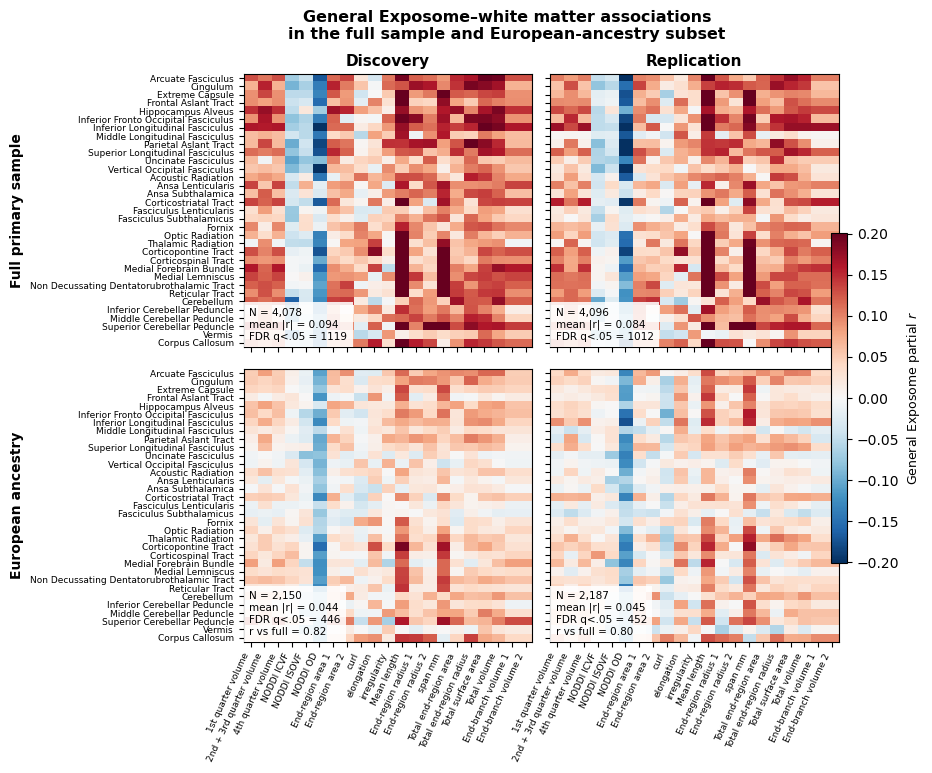

41171

In [19]:
# ============================================================
# Full sample vs European-ancestry stratified heatmap
# ============================================================

import gc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import pearsonr

plt.close("all")
gc.collect()

# Prepare effect maps
effects = {}
for split in ["A", "B"]:
    effects[(split, "full")] = parse_results(general_mu[split])
    effects[(split, "eur")] = parse_results(eur_mu[split])

mats = {}
for split in ["A", "B"]:
    mats[(split, "full")] = make_matrix(effects[(split, "full")])
    mats[(split, "eur")] = make_matrix(effects[(split, "eur")])

# Common effect-size scale across all panels
vals = np.concatenate([m.to_numpy().ravel() for m in mats.values()])
vals = vals[np.isfinite(vals)]
vmax = np.nanpercentile(np.abs(vals), 98)
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Participant Ns
n_full = {
    "A": int(eur_summary.loc[eur_summary["split"] == "A", "n_primary"].iloc[0]),
    "B": int(eur_summary.loc[eur_summary["split"] == "B", "n_primary"].iloc[0]),
}

n_eur = {
    "A": int(eur_summary.loc[eur_summary["split"] == "A", "n"].iloc[0]),
    "B": int(eur_summary.loc[eur_summary["split"] == "B", "n"].iloc[0]),
}

# Panel statistics
panel_stats = {}

for split in ["A", "B"]:
    full = general_mu[split]
    eur = eur_mu[split]

    panel_stats[(split, "full")] = {
        "n": n_full[split],
        "mean_abs_r": float(np.mean(np.abs(full["partial_r"]))),
        "n_fdr": int((full["p_fdr"] < .05).sum()),
    }

    full_comp = full[["feature", "partial_r"]].rename(columns={"partial_r": "r_full"})
    eur_comp = eur[["feature", "partial_r"]].rename(columns={"partial_r": "r_eur"})
    comp = full_comp.merge(eur_comp, on="feature", validate="one_to_one")

    panel_stats[(split, "eur")] = {
        "n": n_eur[split],
        "mean_abs_r": float(np.mean(np.abs(eur["partial_r"]))),
        "n_fdr": int((eur["p_fdr"] < .05).sum()),
        "map_r": pearsonr(comp["r_full"], comp["r_eur"])[0],
    }

# Plot
fig, axes = plt.subplots(2, 2, figsize=(8.5, 8), sharex=True, sharey=True)

for col, split in enumerate(["A", "B"]):
    split_name = "Discovery" if split == "A" else "Replication"
    axes[0, col].set_title(split_name, fontsize=11, fontweight="bold")

    for row, model in enumerate(["full", "eur"]):
        ax = axes[row, col]

        im = ax.imshow(
            mats[(split, model)].to_numpy(),
            aspect="auto",
            cmap="RdBu_r",
            norm=norm,
            interpolation="nearest")

        s = panel_stats[(split, model)]

        text = (
            f"N = {s['n']:,}\n"
            f"mean |r| = {s['mean_abs_r']:.3f}\n"
            f"FDR q<.05 = {s['n_fdr']}")

        if model == "eur":
            text += f"\nr vs full = {s['map_r']:.2f}"

        ax.text(
            .02, .02, text,
            transform=ax.transAxes,
            fontsize=7.5,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=.88))

axes[0, 0].set_ylabel("Full primary sample", fontsize=10, fontweight="bold")
axes[1, 0].set_ylabel("European ancestry", fontsize=10, fontweight="bold")

metric_labels = [pretty_metric(x) for x in METRIC_ORDER]

for ax in axes[-1, :]:
    ax.set_xticks(np.arange(len(METRIC_ORDER)))
    ax.set_xticklabels(metric_labels, rotation=65, ha="right", fontsize=6.5)

for row in range(2):
    axes[row, 0].set_yticks(np.arange(len(TRACT_ORDER)))
    axes[row, 0].set_yticklabels(TRACT_LABELS, fontsize=6.5)

for ax in axes[:, 1]:
    ax.tick_params(axis="y", labelleft=False)

cbar = fig.colorbar(im, ax=axes, fraction=.025, pad=.025, shrink=.80)
cbar.set_label(r"General Exposome partial $r$", fontsize=9)

fig.suptitle(
    "General Exposome–white matter associations\n"
    "in the full sample and European-ancestry subset",
    fontsize=11.5,
    fontweight="bold",
    y=.98
)

fig.subplots_adjust(
    left=.19,
    right=.89,
    bottom=.19,
    top=.90,
    wspace=.06,
    hspace=.08
)

out_path = ANCESTRY_OUTPUT_DIR / "Full_vs_EUR_mass_univariate_heatmap.png"
fig.savefig(out_path, dpi=250)

print("Saved:", out_path)
plt.show()

plt.close(fig)
gc.collect()